# B마트 V2 실제 입고·미입고 반영 보완

이 노트북은 기존 수요예측 모델을 다시 학습하지 않고, 서비스 결과에 **발주→입고 예정→부분입고/지연→재고 포지션→발주량 재계산**을 추가합니다.

핵심 가설은 다음과 같습니다.

> 이미 발주했지만 아직 도착하지 않은 수량을 재고 포지션에 포함하면, 목표재고를 유지하면서 중복 발주를 줄일 수 있다.

실제 발주·입고 파일이 없을 때는 결과를 실제 운영 실적으로 오해하지 않도록 모든 행에 `data_origin=simulation`을 기록합니다. 시뮬레이션은 파이프라인 검증용이며 실제 서비스 수준 개선의 증거가 아닙니다.

In [1]:
# Colab에서 실행 가능한 최소 환경
import hashlib
import json
import os
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)

POLICY_CONFIG = {
    "random_seed": SEED,
    "normal_receipt_weight": 1.0,
    "delayed_receipt_weight": 0.70,
    "cancelled_receipt_weight": 0.0,
    "minimum_supplier_reliability": 0.50,
    "simulation_delay_probability": 0.18,
    "simulation_partial_probability": 0.14,
    "simulation_cancel_probability": 0.02,
}

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print(json.dumps(POLICY_CONFIG, ensure_ascii=False, indent=2))

mkdir -p failed for path C:\Users\dlrkd\AppData\Local\matplotlib: [WinError 5] 액세스가 거부되었습니다: 'C:\\Users\\dlrkd\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\dlrkd\AppData\Local\Temp\matplotlib-6z6jijm5 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Python: 3.12.13
pandas: 3.0.1
numpy: 2.3.5
{
  "random_seed": 42,
  "normal_receipt_weight": 1.0,
  "delayed_receipt_weight": 0.7,
  "cancelled_receipt_weight": 0.0,
  "minimum_supplier_reliability": 0.5,
  "simulation_delay_probability": 0.18,
  "simulation_partial_probability": 0.14,
  "simulation_cancel_probability": 0.02
}


## 1. 데이터 연결과 출처 판정

Colab에서는 Drive 경로를 우선 사용합니다. 실제 `purchase_orders.csv`와 `receipt_history.csv`가 모두 있으면 실제 데이터를 사용하고, 하나라도 없으면 재현 가능한 시뮬레이션을 생성합니다. 실제/모의 데이터가 조용히 섞이는 것을 방지하기 위한 선택입니다.

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('로컬 실행: Google Drive 마운트를 생략합니다.')

DEFAULT_BASE = Path('/content/drive/MyDrive/MBCA/Machine Learning/project')
SERVICE_PATH = Path(os.environ.get('BMART_SERVICE_PATH', DEFAULT_BASE / 'Bmart_v2_service_result.csv'))
PURCHASE_PATH = Path(os.environ.get('BMART_PURCHASE_PATH', DEFAULT_BASE / 'Bmart_purchase_orders.csv'))
RECEIPT_PATH = Path(os.environ.get('BMART_RECEIPT_PATH', DEFAULT_BASE / 'Bmart_receipt_history.csv'))
OUTPUT_DIR = Path(os.environ.get('BMART_RECEIPT_OUTPUT_DIR', DEFAULT_BASE / 'Bmart_receipt_outputs'))

if not SERVICE_PATH.exists():
    raise FileNotFoundError(f'서비스 결과 파일을 찾을 수 없습니다: {SERVICE_PATH}')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
service = pd.read_csv(SERVICE_PATH)
service['date'] = pd.to_datetime(service['date'])
service_hash = hashlib.sha256(SERVICE_PATH.read_bytes()).hexdigest()

required_service = {
    'date', 'store_id', 'product_id', 'category', 'inventory_level',
    'recommended_target_stock', 'recommended_order_qty', 'demand_qty'
}
missing = sorted(required_service - set(service.columns))
if missing:
    raise ValueError(f'서비스 결과 필수 컬럼 누락: {missing}')

USE_ACTUAL_RECEIPTS = PURCHASE_PATH.exists() and RECEIPT_PATH.exists()
DATA_ORIGIN = 'actual' if USE_ACTUAL_RECEIPTS else 'simulation'
print('서비스 파일:', SERVICE_PATH)
print('SHA256:', service_hash)
print('입고 데이터 출처:', DATA_ORIGIN)
print('분석 기간:', service['date'].min().date(), '~', service['date'].max().date())

로컬 실행: Google Drive 마운트를 생략합니다.
서비스 파일: C:\Users\dlrkd\Documents\Codex\2026-08-16\referenced-chatgpt-conversation-this-is-an\outputs\Bmart_v8_run\Bmart_v2_service_result.csv
SHA256: a1d31eba5fccbff774258a3ab51ecf7b05021abbf59132e78bb61f7f959eaa34
입고 데이터 출처: simulation
분석 기간: 2023-11-01 ~ 2024-01-30


## 2. 발주·입고 표준 스키마

- 발주 테이블은 발주 당시 확정된 정보 한 행을 보관합니다.
- 입고 테이블은 분할 입고를 허용하므로 하나의 발주번호에 여러 행이 올 수 있습니다.
- `information_available_date`는 해당 사실을 언제 알 수 있었는지 나타내며, 기준일 이후 정보가 발주 계산에 들어가는 데이터 누수를 막습니다.

In [3]:
SUPPLIER_BY_CATEGORY = {
    category: f'SUP-{index + 1:02d}'
    for index, category in enumerate(sorted(service['category'].astype(str).unique()))
}
LEADTIME_BY_CATEGORY = {
    category: 3 + (index % 4)
    for index, category in enumerate(sorted(service['category'].astype(str).unique()))
}

if USE_ACTUAL_RECEIPTS:
    purchase_orders = pd.read_csv(PURCHASE_PATH)
    receipts = pd.read_csv(RECEIPT_PATH)
    purchase_orders['data_origin'] = 'actual'
    receipts['data_origin'] = 'actual'
else:
    candidates = service.loc[service['recommended_order_qty'].gt(0)].copy().reset_index(drop=True)
    candidates['purchase_order_id'] = [f'PO-SIM-{i + 1:07d}' for i in range(len(candidates))]
    candidates['supplier_id'] = candidates['category'].astype(str).map(SUPPLIER_BY_CATEGORY)
    candidates['order_date'] = candidates['date']
    candidates['ordered_qty'] = candidates['recommended_order_qty'].round().astype(int)
    candidates['planned_lead_time_days'] = candidates['category'].astype(str).map(LEADTIME_BY_CATEGORY)
    candidates['expected_arrival_date'] = candidates['order_date'] + pd.to_timedelta(candidates['planned_lead_time_days'], unit='D')
    candidates['cancelled_flag'] = rng.random(len(candidates)) < POLICY_CONFIG['simulation_cancel_probability']
    candidates['data_origin'] = 'simulation'
    purchase_orders = candidates[[
        'purchase_order_id', 'store_id', 'product_id', 'category', 'supplier_id',
        'order_date', 'expected_arrival_date', 'ordered_qty',
        'planned_lead_time_days', 'cancelled_flag', 'data_origin'
    ]].copy()

    receipt_rows = []
    for row in purchase_orders.itertuples(index=False):
        if row.cancelled_flag:
            continue
        delayed = rng.random() < POLICY_CONFIG['simulation_delay_probability']
        delay_days = int(rng.integers(1, 5)) if delayed else int(rng.choice([-1, 0, 0, 0, 1]))
        arrival = row.expected_arrival_date + pd.Timedelta(days=delay_days)
        partial = row.ordered_qty >= 2 and rng.random() < POLICY_CONFIG['simulation_partial_probability']
        if partial:
            first_qty = max(1, int(np.floor(row.ordered_qty * rng.uniform(0.45, 0.80))))
            quantities = [(arrival, first_qty), (arrival + pd.Timedelta(days=int(rng.integers(1, 4))), row.ordered_qty - first_qty)]
        else:
            quantities = [(arrival, row.ordered_qty)]
        for sequence, (actual_date, qty) in enumerate(quantities, start=1):
            receipt_rows.append({
                'receipt_id': f'{row.purchase_order_id}-R{sequence}',
                'purchase_order_id': row.purchase_order_id,
                'actual_arrival_date': actual_date,
                'information_available_date': actual_date,
                'received_qty': int(qty),
                'data_origin': 'simulation',
            })
    receipts = pd.DataFrame(receipt_rows)

date_columns_po = ['order_date', 'expected_arrival_date']
date_columns_receipt = ['actual_arrival_date', 'information_available_date']
for col in date_columns_po:
    purchase_orders[col] = pd.to_datetime(purchase_orders[col], errors='coerce')
for col in date_columns_receipt:
    receipts[col] = pd.to_datetime(receipts[col], errors='coerce')

print('발주 행:', len(purchase_orders), '입고 이벤트:', len(receipts))
display(purchase_orders.head(3))
display(receipts.head(3))

발주 행: 2157 입고 이벤트: 2399


,purchase_order_id,store_id,product_id,category,supplier_id,order_date,expected_arrival_date,ordered_qty,planned_lead_time_days,cancelled_flag,data_origin
0,PO-SIM-0000001,S001,P0002,Clothing,SUP-01,2023-11-01,2023-11-04,39,3,False,simulation
1,PO-SIM-0000002,S001,P0004,Electronics,SUP-02,2023-11-01,2023-11-05,62,4,False,simulation
2,PO-SIM-0000003,S001,P0008,Electronics,SUP-02,2023-11-01,2023-11-05,14,4,False,simulation


,receipt_id,purchase_order_id,actual_arrival_date,information_available_date,received_qty,data_origin
0,PO-SIM-0000001-R1,PO-SIM-0000001,2023-11-05,2023-11-05,23,simulation
1,PO-SIM-0000001-R2,PO-SIM-0000001,2023-11-07,2023-11-07,16,simulation
2,PO-SIM-0000002-R1,PO-SIM-0000002,2023-11-06,2023-11-06,62,simulation


## 3. 품질 검증과 입고 상태 판정

음수 수량, 중복 ID, 입고일 역전, 발주량 초과 입고는 재고 포지션을 왜곡하므로 즉시 중단합니다. 입고 상태는 수기 입력 대신 누적 입고량과 기준일로 재계산합니다.

In [4]:
required_po = {
    'purchase_order_id', 'store_id', 'product_id', 'supplier_id', 'order_date',
    'expected_arrival_date', 'ordered_qty', 'cancelled_flag', 'data_origin'
}
required_receipt = {
    'receipt_id', 'purchase_order_id', 'actual_arrival_date',
    'information_available_date', 'received_qty', 'data_origin'
}
if required_po - set(purchase_orders.columns):
    raise ValueError(f'발주 컬럼 누락: {sorted(required_po - set(purchase_orders.columns))}')
if required_receipt - set(receipts.columns):
    raise ValueError(f'입고 컬럼 누락: {sorted(required_receipt - set(receipts.columns))}')
if purchase_orders['purchase_order_id'].duplicated().any():
    raise ValueError('purchase_order_id가 중복되었습니다.')
if receipts['receipt_id'].duplicated().any():
    raise ValueError('receipt_id가 중복되었습니다.')
if (purchase_orders['ordered_qty'] < 0).any() or (receipts['received_qty'] < 0).any():
    raise ValueError('발주·입고 수량은 음수가 될 수 없습니다.')
if (~receipts['purchase_order_id'].isin(purchase_orders['purchase_order_id'])).any():
    raise ValueError('발주 원장이 없는 입고가 있습니다.')
if (receipts['information_available_date'] < receipts['actual_arrival_date']).any():
    raise ValueError('정보 인지일이 실제 입고일보다 빠를 수 없습니다.')

received_total = receipts.groupby('purchase_order_id', as_index=False)['received_qty'].sum().rename(columns={'received_qty': 'cumulative_received_qty'})
orders = purchase_orders.merge(received_total, on='purchase_order_id', how='left')
orders['cumulative_received_qty'] = orders['cumulative_received_qty'].fillna(0)
if (orders['cumulative_received_qty'] > orders['ordered_qty']).any():
    raise ValueError('누적 입고량이 발주량을 초과한 발주가 있습니다.')

orders['remaining_qty'] = (orders['ordered_qty'] - orders['cumulative_received_qty']).clip(lower=0)
last_receipt = receipts.groupby('purchase_order_id', as_index=False)['actual_arrival_date'].max()
orders = orders.merge(last_receipt, on='purchase_order_id', how='left')
orders['actual_lead_time_days'] = (orders['actual_arrival_date'] - orders['order_date']).dt.days
orders['delay_days'] = (orders['actual_arrival_date'] - orders['expected_arrival_date']).dt.days
orders['receipt_status'] = np.select(
    [
        orders['cancelled_flag'],
        orders['cumulative_received_qty'].ge(orders['ordered_qty']),
        orders['cumulative_received_qty'].gt(0),
    ],
    ['발주 취소', '입고 완료', '부분 입고'],
    default='입고 예정',
)

print('데이터 품질 검사 통과')
display(orders['receipt_status'].value_counts(dropna=False).rename_axis('status').to_frame('orders'))

데이터 품질 검사 통과


,orders
status,
입고 완료,2121
발주 취소,36


## 4. 공급처 리드타임 근거

평균은 지연 꼬리를 숨길 수 있으므로 중앙값과 P90을 함께 봅니다. 정시입고율과 완전입고율은 지연 발주의 입고예정량을 얼마나 신뢰할지 판단하는 보조 근거입니다. 이 표는 사후 평가용이며, 과거 기준일 발주 계산에는 미래 완료 정보를 사용하지 않습니다.

,supplier_id,total_orders,complete_orders,average_lead_time,median_lead_time,p90_lead_time,on_time_rate,complete_fill_rate
0,SUP-01,495,486,3.737,3.0,6.0,0.603,0.982
1,SUP-02,242,240,4.800,4.0,7.0,0.538,0.992
2,SUP-03,208,207,5.792,5.0,8.0,0.556,0.995
3,SUP-04,785,770,6.753,6.0,9.0,0.562,0.981
4,SUP-05,427,418,3.608,3.0,6.0,0.605,0.979


C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3010719349.py:19: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3010719349.py:19: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3010719349.py:19: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3010719349.py:19: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3010719349.py:19: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3010719349.py:19: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing 

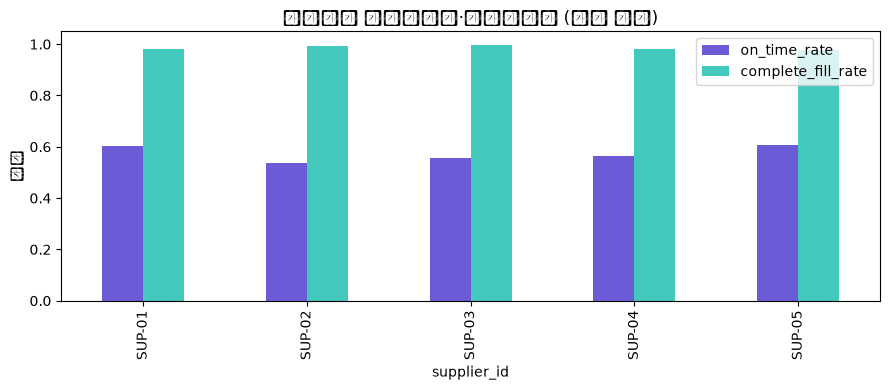

In [5]:
completed = orders.loc[orders['receipt_status'].eq('입고 완료')].copy()
supplier_summary = (
    orders.groupby('supplier_id')
    .agg(total_orders=('purchase_order_id', 'size'), complete_orders=('receipt_status', lambda s: s.eq('입고 완료').sum()))
)
leadtime_summary = completed.groupby('supplier_id').agg(
    average_lead_time=('actual_lead_time_days', 'mean'),
    median_lead_time=('actual_lead_time_days', 'median'),
    p90_lead_time=('actual_lead_time_days', lambda s: s.quantile(0.90)),
    on_time_rate=('delay_days', lambda s: s.le(0).mean()),
)
supplier_summary = supplier_summary.join(leadtime_summary, how='left').reset_index()
supplier_summary['complete_fill_rate'] = supplier_summary['complete_orders'] / supplier_summary['total_orders']
display(supplier_summary.round(3))

ax = supplier_summary.plot.bar(x='supplier_id', y=['on_time_rate', 'complete_fill_rate'], ylim=(0, 1.05), figsize=(9, 4), color=['#6c5bd6', '#43c8bd'])
ax.set_title('공급처별 정시입고율·완전입고율 (사후 평가)')
ax.set_ylabel('비율')
plt.tight_layout()
plt.show()

## 5. 기준일 스냅샷과 데이터 누수 차단

각 발주 추천일에는 그날까지 실제로 알려진 입고만 차감합니다. 이후에 발생한 입고 결과나 최종 리드타임은 입력으로 사용하지 않습니다. 지연된 미입고량은 불확실성을 반영해 70%만 유효 입고예정으로 인정하며, 이 비율은 민감도 분석 대상입니다.

In [6]:
def known_pipeline_as_of(decision_date, purchase_orders, receipts, delayed_weight=0.70):
    decision_date = pd.Timestamp(decision_date)
    placed = purchase_orders.loc[
        purchase_orders['order_date'].lt(decision_date)
        & ~purchase_orders['cancelled_flag']
    ].copy()
    known_receipts = receipts.loc[receipts['information_available_date'].le(decision_date)].copy()
    known_qty = known_receipts.groupby('purchase_order_id', as_index=False)['received_qty'].sum().rename(columns={'received_qty': 'known_received_qty'})
    placed = placed.merge(known_qty, on='purchase_order_id', how='left')
    placed['known_received_qty'] = placed['known_received_qty'].fillna(0)
    placed['open_qty'] = (placed['ordered_qty'] - placed['known_received_qty']).clip(lower=0)
    placed = placed.loc[placed['open_qty'].gt(0)].copy()
    placed['known_status'] = np.where(placed['expected_arrival_date'].lt(decision_date), '입고 지연', '입고 예정')
    placed['receipt_weight'] = np.where(placed['known_status'].eq('입고 지연'), delayed_weight, 1.0)
    placed['effective_incoming_qty'] = placed['open_qty'] * placed['receipt_weight']
    return placed

snapshots = []
for decision_date in sorted(service['date'].unique()):
    open_as_of = known_pipeline_as_of(decision_date, purchase_orders, receipts, POLICY_CONFIG['delayed_receipt_weight'])
    if open_as_of.empty:
        continue
    daily = open_as_of.groupby(['store_id', 'product_id'], as_index=False).agg(
        incoming_order_qty=('open_qty', 'sum'),
        effective_incoming_qty=('effective_incoming_qty', 'sum'),
        open_purchase_orders=('purchase_order_id', 'nunique'),
    )
    daily['date'] = pd.Timestamp(decision_date)
    snapshots.append(daily)

pipeline = pd.concat(snapshots, ignore_index=True) if snapshots else pd.DataFrame(columns=[
    'store_id', 'product_id', 'incoming_order_qty', 'effective_incoming_qty', 'open_purchase_orders', 'date'
])

# 기존 서비스 파일의 incoming_order_qty는 실제 입고 원장이 없어 0으로 둔 placeholder다.
# 새 기준일 스냅샷으로 교체해 suffix 충돌과 이중 계산을 막는다.
service_for_receipts = service.drop(
    columns=['incoming_order_qty', 'inventory_position'], errors='ignore'
)
decision = service_for_receipts.merge(
    pipeline, on=['date', 'store_id', 'product_id'], how='left'
)
for col in ['incoming_order_qty', 'effective_incoming_qty', 'open_purchase_orders']:
    decision[col] = decision[col].fillna(0)

# 누수 방지 확인: 기준일 이후 인지된 입고는 어떤 스냅샷에도 known receipt로 포함되지 않는다.
sample_dates = sorted(service['date'].unique())[::max(1, len(service['date'].unique()) // 8)]
for decision_date in sample_dates:
    known = receipts.loc[receipts['information_available_date'].le(pd.Timestamp(decision_date))]
    assert known['information_available_date'].le(pd.Timestamp(decision_date)).all()
print('기준일 스냅샷 누수 검사 통과:', len(sample_dates), '개 기준일')

기준일 스냅샷 누수 검사 통과: 9 개 기준일


## 6. 입고 반영 발주량과 정책 비교

기존 권장량은 현재고 중심 결과이고, 개선안은 `목표재고 - 현재고 - 유효 입고예정량 + 미납`을 사용합니다. 현재 원천 데이터에는 실제 미납이 없어 0으로 둡니다. 운영 적용 시 ERP 미납 필드로 교체해야 합니다.

여기서는 실제 재고 이동 원장이 없으므로 서비스 수준 개선을 주장하지 않고, 중복 발주 감소와 목표재고 대비 예상 부족량을 비교합니다.

In [7]:
decision['backorder_qty'] = 0.0
decision['receipt_adjusted_inventory_position'] = (
    decision['inventory_level']
    + decision['effective_incoming_qty']
    - decision['backorder_qty']
)
decision['receipt_adjusted_order_qty_raw'] = (
    decision['recommended_target_stock'] - decision['receipt_adjusted_inventory_position']
).clip(lower=0)

pack = decision.get('pack_size', pd.Series(1, index=decision.index)).fillna(1).clip(lower=1)
moq = decision.get('minimum_order_qty', pd.Series(0, index=decision.index)).fillna(0).clip(lower=0)
positive = decision['receipt_adjusted_order_qty_raw'].gt(0)
rounded = np.ceil(decision['receipt_adjusted_order_qty_raw'] / pack) * pack
decision['receipt_adjusted_order_qty'] = np.where(positive, np.maximum(rounded, moq), 0).astype(int)
decision['duplicate_order_avoided_qty'] = (
    decision['recommended_order_qty'] - decision['receipt_adjusted_order_qty']
).clip(lower=0)
decision['projected_position_after_order'] = (
    decision['receipt_adjusted_inventory_position'] + decision['receipt_adjusted_order_qty']
)
decision['projected_shortage_to_target'] = (
    decision['recommended_target_stock'] - decision['projected_position_after_order']
).clip(lower=0)

comparison = pd.DataFrame([
    {
        'policy': '기존 권장 발주',
        'total_order_qty': decision['recommended_order_qty'].sum(),
        'orders_with_positive_qty': decision['recommended_order_qty'].gt(0).sum(),
        'duplicate_order_avoided_qty': 0,
        'projected_shortage_to_target': np.maximum(decision['recommended_target_stock'] - decision['inventory_level'] - decision['recommended_order_qty'], 0).sum(),
    },
    {
        'policy': '입고예정 반영 발주',
        'total_order_qty': decision['receipt_adjusted_order_qty'].sum(),
        'orders_with_positive_qty': decision['receipt_adjusted_order_qty'].gt(0).sum(),
        'duplicate_order_avoided_qty': decision['duplicate_order_avoided_qty'].sum(),
        'projected_shortage_to_target': decision['projected_shortage_to_target'].sum(),
    },
])
display(comparison)
print('주의: 위 부족량은 재고 이동 원장 없이 계산한 계획 시점 대리 지표입니다.')

,policy,total_order_qty,orders_with_positive_qty,duplicate_order_avoided_qty,projected_shortage_to_target
0,기존 권장 발주,110579,2157,0,0.0
1,입고예정 반영 발주,48511,1040,62068,0.0


주의: 위 부족량은 재고 이동 원장 없이 계산한 계획 시점 대리 지표입니다.


## 7. 지연 입고 인정률 민감도

지연 발주를 100% 믿으면 중복 발주는 가장 적지만 미입고 위험을 과소평가합니다. 0%로 보면 안전하지만 중복 발주가 증가할 수 있습니다. 하나의 임의값을 정답처럼 제시하지 않고 여러 인정률의 결과를 비교합니다.

,delayed_receipt_weight,total_adjusted_order_qty,order_reduction_vs_current
0,0.0,51575,59004
1,0.5,49081,61498
2,0.7,48511,62068
3,1.0,47977,62602


C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3859538975.py:29: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3859538975.py:29: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3859538975.py:29: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3859538975.py:29: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3859538975.py:29: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dlrkd\AppData\Local\Temp\ipykernel_22736\3859538975.py:29: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing f

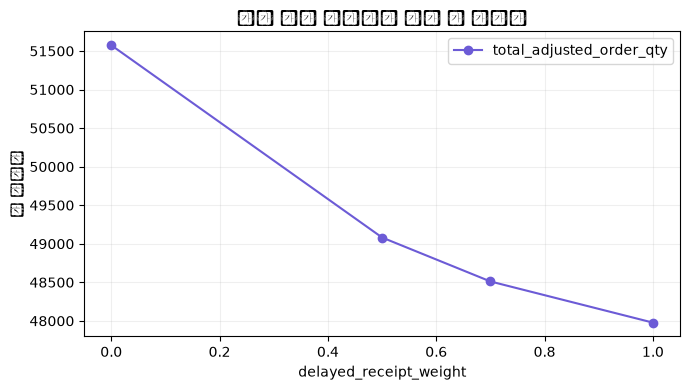

In [8]:
sensitivity_rows = []
for weight in [0.0, 0.5, 0.7, 1.0]:
    weighted_snapshots = []
    for decision_date in sorted(service['date'].unique()):
        open_as_of = known_pipeline_as_of(decision_date, purchase_orders, receipts, weight)
        if open_as_of.empty:
            continue
        daily = open_as_of.groupby(['store_id', 'product_id'], as_index=False)['effective_incoming_qty'].sum()
        daily['date'] = pd.Timestamp(decision_date)
        weighted_snapshots.append(daily)
    weighted = pd.concat(weighted_snapshots, ignore_index=True) if weighted_snapshots else pipeline.iloc[0:0][['store_id', 'product_id', 'date', 'effective_incoming_qty']]
    temp = service.merge(weighted, on=['date', 'store_id', 'product_id'], how='left')
    temp['effective_incoming_qty'] = temp['effective_incoming_qty'].fillna(0)
    raw = (temp['recommended_target_stock'] - temp['inventory_level'] - temp['effective_incoming_qty']).clip(lower=0)
    pack_temp = temp.get('pack_size', pd.Series(1, index=temp.index)).fillna(1).clip(lower=1)
    adjusted = np.where(raw.gt(0), np.maximum(np.ceil(raw / pack_temp) * pack_temp, temp.get('minimum_order_qty', 0)), 0)
    sensitivity_rows.append({
        'delayed_receipt_weight': weight,
        'total_adjusted_order_qty': int(adjusted.sum()),
        'order_reduction_vs_current': int((temp['recommended_order_qty'] - adjusted).clip(lower=0).sum()),
    })

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)
sensitivity.plot(x='delayed_receipt_weight', y='total_adjusted_order_qty', marker='o', color='#6c5bd6', figsize=(7, 4))
plt.title('지연 입고 인정률에 따른 총 발주량')
plt.ylabel('총 발주량')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8. 산출물과 재현성 기록

대시보드는 `open_orders`와 `receipt_adjusted_order_recommendation`을 연결하면 됩니다. Config에는 데이터 출처와 한계를 포함해 시뮬레이션 결과가 실제 운영 성과로 표시되지 않도록 합니다.

In [9]:
analysis_end = service['date'].max()
open_orders = known_pipeline_as_of(analysis_end, purchase_orders, receipts, POLICY_CONFIG['delayed_receipt_weight'])

config = {
    'analysis_name': 'Bmart receipt-aware replenishment',
    'data_origin': DATA_ORIGIN,
    'service_input': str(SERVICE_PATH),
    'service_input_sha256': service_hash,
    'analysis_end_date': str(analysis_end.date()),
    'policy': POLICY_CONFIG,
    'inventory_position_formula': 'on_hand + effective_incoming - backorders',
    'leakage_control': 'receipts included only when information_available_date <= decision_date',
    'limitations': [
        'Simulation is used when actual PO and receipt files are absent.',
        'Historical inventory snapshots are not a transaction-level inventory ledger.',
        'Projected shortage is a planning proxy, not proven realized service level.',
        'Replace simulated supplier behavior with ERP receipt history before production use.',
    ],
    'versions': {'python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__},
}

files = {
    'Bmart_purchase_orders.csv': purchase_orders,
    'Bmart_receipt_history.csv': receipts,
    'Bmart_open_orders.csv': open_orders,
    'Bmart_supplier_leadtime_summary.csv': supplier_summary,
    'Bmart_receipt_adjusted_order_recommendation.csv': decision,
    'Bmart_receipt_policy_comparison.csv': comparison,
    'Bmart_receipt_weight_sensitivity.csv': sensitivity,
}
for name, frame in files.items():
    frame.to_csv(OUTPUT_DIR / name, index=False, encoding='utf-8-sig')
(OUTPUT_DIR / 'Bmart_receipt_model_config.json').write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')

print('저장 위치:', OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path.name, path.stat().st_size, 'bytes')

저장 위치: C:\Users\dlrkd\Documents\Codex\2026-08-16\referenced-chatgpt-conversation-this-is-an\outputs\Bmart_receipt_run
Bmart_open_orders.csv 13351 bytes
Bmart_purchase_orders.csv 187796 bytes
Bmart_receipt_adjusted_order_recommendation.csv 2263887 bytes
Bmart_receipt_history.csv 167920 bytes
Bmart_receipt_model_config.json 1345 bytes
Bmart_receipt_policy_comparison.csv 198 bytes
Bmart_receipt_weight_sensitivity.csv 147 bytes
Bmart_supplier_leadtime_summary.csv 500 bytes


## 결론 해석 원칙

- 실제 파일 사용 시에도 시점 누수 검사를 통과해야 합니다.
- 모의 데이터 사용 결과는 구현 가능성과 계산 흐름의 검증입니다.
- 운영 효과 입증에는 실제 발주·분할입고·취소·재고 이동 원장으로 동일 기간의 정책 백테스트가 필요합니다.
- 지연 입고 인정률은 비용과 서비스 수준을 함께 비교한 뒤 선택해야 합니다.